## STEP 2 - TEXTUAL PREPROCESSING
#### In this step, we're coing to clean the texts before models training.

In [1]:
import pandas as pd
from pipeline.preprocessor import Preprocessor 
from pipeline.encoders.tfidf import TFIDFTokenizer
from pipeline.encoders.w2v import Word2VecTokenizer


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
df = pd.read_csv("data/augmented_datasets/mbti_augmented_qwen.csv")

In [4]:
df.head()

,Unnamed: 0,type,posts,augmented_posts
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o..."
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc..."


In [5]:
pre = Preprocessor("augmented_posts")

In [6]:
df = pre.preprocess_complete(df)

In [7]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...


In [8]:
pre2 = Preprocessor("posts")
df = pre2.preprocess_complete(df)

In [9]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...


In [10]:
df.to_csv("data/clean_datasets/qwen_cleaned_dataset.csv", index = False)

In [13]:
df["posts_clean"] = df["posts_clean"].fillna("")                                                     
df["augmented_posts_clean"] = df["augmented_posts_clean"].fillna("")   

In [17]:
tfidf_tokenizer = TFIDFTokenizer()                                                                   
                                                                                                        
# 2. Fit and transform the clean texts column from your dataframe                                    
# This will return a sparse matrix of TF-IDF features                                                
X_tfidf = tfidf_tokenizer.fit_transform(df["posts_clean"])                                           
                                                                                                        
# Let's check the shape (number of documents, number of features)                                    
print(f"TF-IDF Shape: {X_tfidf.shape}")   

TF-IDF Shape: (8675, 10000)


In [18]:
df["posts_tfidf_features"] = list(X_tfidf.toarray())                                                       
                                                                          
df[["posts_clean", "posts_tfidf_features"]].head()

,posts_clean,posts_tfidf_features
0,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055..."
2,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934..."
3,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,..."
4,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [19]:
w2v_tokenizer = Word2VecTokenizer()                                                                  
                                                                                                    
w2v_tokenizer.fit(df["posts_clean"])  

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [20]:
df["posts_w2v_features"] = df["posts_clean"].apply(w2v_tokenizer.get_document_embedding)         
  
df[["posts_clean", "posts_w2v_features"]].head()

,posts_clean,posts_w2v_features
0,moment sportscenter top ten play prank ha life...,"[0.039469853, -0.3728942, -0.41033414, -0.1154..."
1,i finding lack me post alarming sex boring pos...,"[0.078822784, -0.31084794, -0.40682986, -0.102..."
2,good one course i say i know blessing curse do...,"[0.055956766, -0.31570536, -0.36344454, -0.075..."
3,dear i enjoyed conversation day esoteric gabbi...,"[-0.019194897, -0.37407914, -0.5568112, -0.182..."
4,you fired another silly misconception approach...,"[0.057541147, -0.29415804, -0.45218706, -0.204..."


In [21]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154..."
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102..."
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075..."
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182..."
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204..."


In [22]:
tfidf_tokenizer = TFIDFTokenizer()                                                                   
                                                                                                        
# 2. Fit and transform the clean texts column from your dataframe                                    
# This will return a sparse matrix of TF-IDF features                                                
X_tfidf = tfidf_tokenizer.fit_transform(df["augmented_posts_clean"])                                           
                                                                                                        
# Let's check the shape (number of documents, number of features)                                    
print(f"TF-IDF Shape: {X_tfidf.shape}")   

TF-IDF Shape: (8675, 10000)


In [23]:
df["augmented_posts_tfidf_features"] = list(X_tfidf.toarray())                                                       
                                                                          
df[["augmented_posts_clean", "augmented_posts_tfidf_features"]].head()

,augmented_posts_clean,augmented_posts_tfidf_features
0,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,i noticing significant absence post sex monoto...,"[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183..."
2,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032..."
3,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,..."
4,you fired another common misconception approac...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [24]:
w2v_tokenizer = Word2VecTokenizer()                                                                  
                                                                                                    
w2v_tokenizer.fit(df["posts_clean"])  

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [25]:
df["augmented_posts_w2v_features"] = df["augmented_posts_clean"].apply(w2v_tokenizer.get_document_embedding)         
  
df[["augmented_posts_clean", "augmented_posts_w2v_features"]].head()

,augmented_posts_clean,augmented_posts_w2v_features
0,moment sportscenter top ten play prank ha life...,"[0.19693445, -0.0025032638, 0.08193041, 0.1530..."
1,i noticing significant absence post sex monoto...,"[0.22643407, 0.13486987, 0.13359053, 0.1418835..."
2,good one course i say i know blessing curse do...,"[0.19347186, 0.021339012, 0.09674486, 0.159254..."
3,dear i enjoyed conversation day esoteric gabbi...,"[0.21894899, 0.21582802, 0.18478529, 0.2388864..."
4,you fired another common misconception approac...,"[0.19203198, 0.121340014, -0.008840058, 0.0499..."


In [26]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features,augmented_posts_tfidf_features,augmented_posts_w2v_features
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19693445, -0.0025032638, 0.08193041, 0.1530..."
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102...","[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[0.22643407, 0.13486987, 0.13359053, 0.1418835..."
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075...","[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.19347186, 0.021339012, 0.09674486, 0.159254..."
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[0.21894899, 0.21582802, 0.18478529, 0.2388864..."
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19203198, 0.121340014, -0.008840058, 0.0499..."


In [31]:
df.to_pickle('final_dataset_with_encodings.pkl')

In [30]:
df['I_E'] = df['type'].str[0]  # Introversion (I) / Extraversion (E)
df['N_S'] = df['type'].str[1]  # Intuition (N) / Sensing (S)
df['T_F'] = df['type'].str[2]  # Thinking (T) / Feeling (F)
df['J_P'] = df['type'].str[3]  # Judging (J) / Perceiving (P)

In [43]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,augmented_posts_tfidf_features,augmented_posts_w2v_features,posts_tfidf_features,posts_w2v_features,I_E,N_S,T_F,J_P
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.002159971, -0.14343101, -0.12050654, -0.050...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.13236128, -0.14389294, -0.20428565, -0.1651...",I,N,F,J
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[-0.004108996, -0.21367836, -0.12613854, 0.011...","[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.1626075, 0.0044341884, -0.19206956, -0.1163...",E,N,T,P
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.031872004, -0.21123065, -0.10102697, 0.1168...","[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.094802484, -0.026353495, -0.22625083, -0.12...",I,N,T,P
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[-0.020057147, -0.28583112, -0.16146983, 0.031...","[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[0.16887033, 0.092762336, -0.12733975, -0.0991...",I,N,T,J
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.025633927, -0.064314075, -0.064204596, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.20505299, 0.052702054, -0.17148761, -0.1408...",E,N,T,J


In [44]:
df.to_csv('full_dataset_with_embeddings_augmented_qwen.csv')

In [32]:
df.head()

,Unnamed: 0,type,posts,augmented_posts,augmented_posts_clean,posts_clean,posts_tfidf_features,posts_w2v_features,augmented_posts_tfidf_features,augmented_posts_w2v_features,I_E,N_S,T_F,J_P
0,0,INFJ,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,'http://www.youtube.com/watch?v=qsXHcwe3krw|||...,moment sportscenter top ten play prank ha life...,moment sportscenter top ten play prank ha life...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.039469853, -0.3728942, -0.41033414, -0.1154...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19693445, -0.0025032638, 0.08193041, 0.1530...",I,N,F,J
1,1,ENTP,'I'm finding the lack of me in these posts ver...,I am noticing a significant absence of myself ...,i noticing significant absence post sex monoto...,i finding lack me post alarming sex boring pos...,"[0.0, 0.06762042801527685, 0.0, 0.026240045055...","[0.078822784, -0.31084794, -0.40682986, -0.102...","[0.0, 0.0, 0.06401863001877148, 0.0, 0.0308183...","[0.22643407, 0.13486987, 0.13359053, 0.1418835...",E,N,T,P
2,2,INTP,'Good one _____ https://www.youtube.com/wat...,'Good one _____ https://www.youtube.com/wat...,good one course i say i know blessing curse do...,good one course i say i know blessing curse do...,"[0.0, 0.0, 0.07384879322521598, 0.031627841934...","[0.055956766, -0.31570536, -0.36344454, -0.075...","[0.0, 0.0, 0.0, 0.0, 0.0658605765698715, 0.032...","[0.19347186, 0.021339012, 0.09674486, 0.159254...",I,N,T,P
3,3,INTJ,"'Dear INTP, I enjoyed our conversation the o...","'Dear INTP, I enjoyed our conversation the o...",dear i enjoyed conversation day esoteric gabbi...,dear i enjoyed conversation day esoteric gabbi...,"[0.0, 0.0, 0.0, 0.05044068578091325, 0.0, 0.0,...","[-0.019194897, -0.37407914, -0.5568112, -0.182...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.05199321424315832,...","[0.21894899, 0.21582802, 0.18478529, 0.2388864...",I,N,T,J
4,4,ENTJ,'You're fired.|||That's another silly misconce...,"""You're fired."" ||| That's another common misc...",you fired another common misconception approac...,you fired another silly misconception approach...,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.057541147, -0.29415804, -0.45218706, -0.204...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.19203198, 0.121340014, -0.008840058, 0.0499...",E,N,T,J


In [52]:
import pandas as pd                                                                                                            
from sklearn.model_selection import train_test_split                                                                           
import numpy as np

# 1. Importando os Módulos do SEU Pipeline!                                                                                    
from pipeline.encoders.tfidf import TFIDFTokenizer # Você pode trocar pelo Word2Vec ou Bert                                             
from pipeline.smote_oversampling import SMOTEOversampler                                                                       
from pipeline.machine_learning_algorithms.xgboost import XGBoostClassifier                                                 
                                                                                                                                
# ==========================================                                                                                   
# PASSO 1: EXTRAÇÃO DE FEATURES (TEXTO -> NÚMEROS)                                                                             
# ==========================================                                                                                   
print("1. Transformando textos em matriz matemática...")                                                                                                                                                                
X = np.stack(df["augmented_posts_tfidf_features"].values)                                                              
y = df["type"]  # A coluna original com os 16 tipos MBTI                                                                       
                                                                                                                                
# ==========================================                                                                                   
# PASSO 2: DIVISÃO EM TREINO E TESTE                                                                                           
# ==========================================                                                                                   
# ⚠️ REGRA DE OURO: Sempre separe antes de usar o SMOTE!                                                                       
# Se você criar dados falsos no teste, a validação fica roubada.                                                               
print("2. Separando em Treino e Teste...")                                                                                     
X_train, X_test, y_train, y_test = train_test_split(                                                                           
    X, y, test_size=0.2, random_state=42, stratify=y                                                                           
)                                                                                                                              
                                                                                                                                
# ==========================================                                                                                   
# PASSO 3: BALANCEAMENTO (SMOTE)                                                                                               
# ==========================================                                                                                   
print("3. Aplicando SMOTE apenas nos dados de Treino...")                                                                      
smote = SMOTEOversampler(random_state=42)                                                                                      
# Isso vai equilibrar as 16 classes criando novos exemplos matemáticos (apenas no treino)                                      
X_train_balanceado, y_train_balanceado = smote.fit_resample(X_train, y_train)                                                  
                                                                                                                                
# ==========================================                                                                                   
# PASSO 4: DIVIDIR AS CLASSES MBTI NAS 4 COLUNAS BINÁRIAS                                                                      
# ==========================================                                                                                   
def separar_mbti(y_series):                                                                                                    
    """Função rápida pra quebrar a Series 'INTJ' num DataFrame de 4 colunas (1/0)"""                                           
    y_df = pd.DataFrame()                                                                                                      
    y_df['I_E'] = (y_series.str[0] == 'I').astype(int)                                                                        
    y_df['N_S'] = (y_series.str[1] == 'N').astype(int)                                                                        
    y_df['T_F'] = (y_series.str[2] == 'T').astype(int)                                                                        
    y_df['J_P'] = (y_series.str[3] == 'J').astype(int)                                                                        
    return y_df                                                                                                                
                                                                                                                                
print("4. Quebrando os rótulos de Treino e Teste em 4 colunas (I/E, N/S, T/F, J/P)...")                                        
# Usamos a série balanceada no treino, e a original no teste                                                                   
y_train_4cols = separar_mbti(y_train_balanceado)                                                                               
y_test_4cols = separar_mbti(y_test.reset_index(drop=True))                                                                     
                                                                                                                                
# ==========================================                                                                                   
# PASSO 5: TREINAMENTO DOS MODELOS                                                                                             
# ==========================================                                                                                   
print("5. Iniciando o treinamento dos 4 modelos XGBoost...")
mbti_clf = XGBoostClassifier(                                                                                              
    n_estimators=400,        # Aumentamos de 100 para 400 árvores                                                              
    learning_rate=0.05,      # Aprendizado mais lento e cauteloso (ajuda árvores grandes)                                      
    max_depth=8,             # Árvores um pouco mais profundas para pegar sutilezas                                            
    subsample=0.8,           # Previne overfitting no treino                                                                   
    colsample_bytree=0.8                                                                                                       
)    
# Treinamos com os dados balanceados e as 4 colunas
mbti_clf.fit(X_train_balanceado, y_train_4cols)

# ==========================================
# PASSO 6: AVALIAÇÃO DOS RESULTADOS
# ==========================================
print("6. Avaliando como o modelo se sai em textos que ele nunca viu (Teste)...")
# Avaliamos os modelos nas 4 colunas reais, sem interferência sintética do SMOTE
mbti_clf.evaluate(X_test, y_test_4cols)

# ==========================================
# PASSO 7: PREDIÇÃO FINAL (OPCIONAL)
# ==========================================
print("7. Gerando predições reconstruídas!")
previsoes = mbti_clf.predict(X_test)

# Mostra as primeiras 5 predições e a string MBTI remontada (Ex: 'ENTP')
print(previsoes[['predicted_type']].head())

1. Transformando textos em matriz matemática...
2. Separando em Treino e Teste...
3. Aplicando SMOTE apenas nos dados de Treino...
Original dataset shape: X=(6940, 10000), y=(6940,)


/Users/yasmimdantas/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Resampled dataset shape: X=(23456, 10000), y=(23456,)
4. Quebrando os rótulos de Treino e Teste em 4 colunas (I/E, N/S, T/F, J/P)...
5. Iniciando o treinamento dos 4 modelos XGBoost...
Starting training process...
 -> Training model for I_E...
 -> Training model for N_S...
 -> Training model for T_F...
 -> Training model for J_P...
All 4 models trained successfully! ✅
6. Avaliando como o modelo se sai em textos que ele nunca viu (Teste)...

Evaluation for dimension: I_E
Accuracy: 0.9055

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       401
           1       0.93      0.95      0.94      1334

    accuracy                           0.91      1735
   macro avg       0.88      0.85      0.86      1735
weighted avg       0.90      0.91      0.90      1735


Evaluation for dimension: N_S
Accuracy: 0.9014

              precision    recall  f1-score   support

           0       0.71      0.49      0.58       240
           1       0.9

In [53]:
mbti_clf.evaluate(X_test, y_test_4cols) 


Evaluation for dimension: I_E
Accuracy: 0.9055

              precision    recall  f1-score   support

           0       0.82      0.75      0.79       401
           1       0.93      0.95      0.94      1334

    accuracy                           0.91      1735
   macro avg       0.88      0.85      0.86      1735
weighted avg       0.90      0.91      0.90      1735


Evaluation for dimension: N_S
Accuracy: 0.9014

              precision    recall  f1-score   support

           0       0.71      0.49      0.58       240
           1       0.92      0.97      0.94      1495

    accuracy                           0.90      1735
   macro avg       0.82      0.73      0.76      1735
weighted avg       0.89      0.90      0.89      1735


Evaluation for dimension: T_F
Accuracy: 0.7931

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       939
           1       0.78      0.76      0.77       796

    accuracy                       

In [54]:
previsoes.head()

,I_E,N_S,T_F,J_P,predicted_type
0,1,1,0,0,1100
1,1,1,1,0,1110
2,1,1,0,1,1101
3,1,1,1,1,1111
4,1,1,1,0,1110


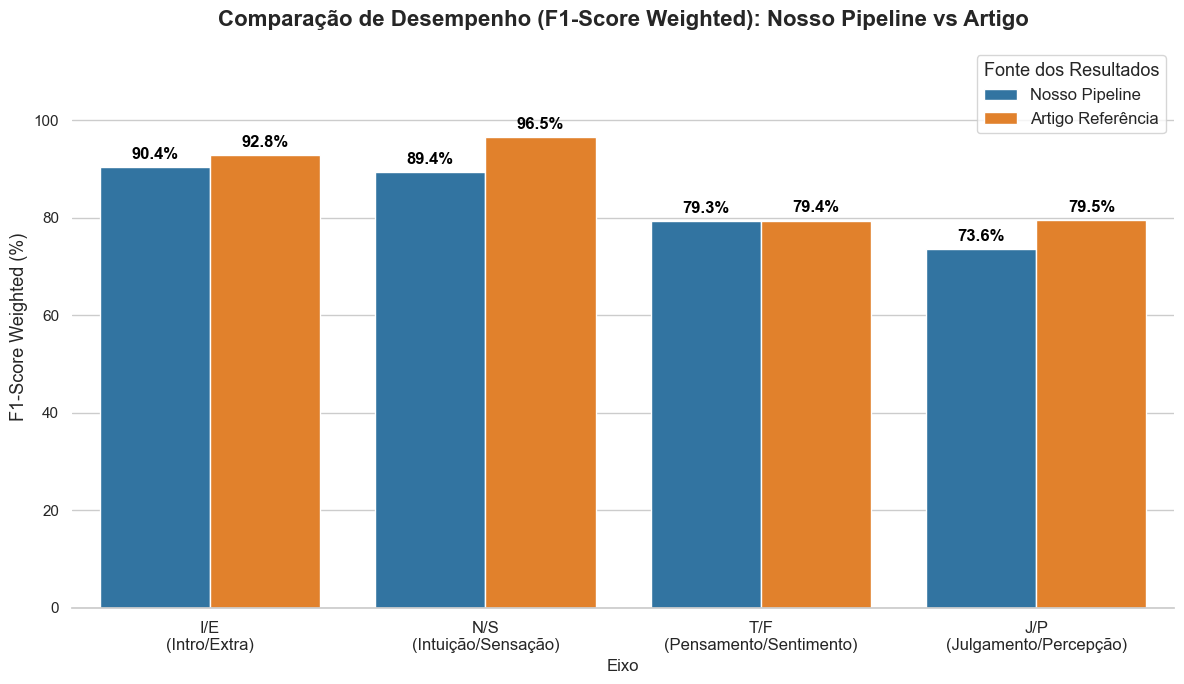

In [58]:
    import matplotlib.pyplot as plt                                                                                                
    import seaborn as sns                                                                                                          
    import pandas as pd                                                                                                            
    from sklearn.metrics import f1_score                                                                                           
                                                                                                                                   
    # 1. Pegamos as predições do conjunto de teste                                                                                 
    predicoes = mbti_clf.predict(X_test)                                                                                           
                                                                                                                                   
    # ATENÇÃO: Confirme se os nomes das colunas são esses mesmos no seu DataFrame                                                  
    colunas_binarias = ['I_E', 'N_S', 'T_F', 'J_P']                                                                            
    nomes_eixos = [                                                                                                                
        'I/E\n(Intro/Extra)',                                                                                                      
        'N/S\n(Intuição/Sensação)',                                                                                                
        'T/F\n(Pensamento/Sentimento)',                                                                                            
        'J/P\n(Julgamento/Percepção)'                                                                                              
    ]                                                                                                                              
                                                                                                                                   
    # 2. Calculamos o F1-Score (Weighted) do SEU modelo                                                                            
    f1_scores_meu_modelo = []                                                                                                      
    for col in colunas_binarias:                                                                                                   
        f1 = f1_score(y_test_4cols[col], predicoes[col], average='weighted')                                                       
        f1_scores_meu_modelo.append(f1 * 100)                                                                                      
                                                                                                                                   
    # 3. Inserimos os F1-Scores do PAPER (conforme a Tabela 11 que você enviou)                                                    
    # Ordem: E-I, N-S, F-T, J-P                                                                                                    
    f1_scores_paper = [92.79, 96.45, 79.38, 79.50]                                                                                 
                                                                                                                                   
    # 4. Criamos um DataFrame organizando os dados para plotar lado a lado                                                         
    dados = []                                                                                                                     
    for i in range(4):                                                                                                             
        dados.append({'Eixo': nomes_eixos[i], 'F1-Score (%)': f1_scores_meu_modelo[i], 'Origem': 'Nosso Pipeline'})                
        dados.append({'Eixo': nomes_eixos[i], 'F1-Score (%)': f1_scores_paper[i], 'Origem': 'Artigo Referência'})                  
                                                                                                                                   
    df_plot = pd.DataFrame(dados)                                                                                                  
                                                                                                                                   
    # ==========================================                                                                                   
    # 5. CONSTRUÇÃO DO GRÁFICO (LADO A LADO)                                                                                       
    # ==========================================                                                                                   
    plt.figure(figsize=(12, 7))                                                                                                    
    sns.set_theme(style="whitegrid")                                                                                               
                                                                                                                                   
    # Criando o gráfico com barras agrupadas (hue='Origem')                                                                        
    # Escolha da paleta: azul para o seu, laranja para o paper                                                                     
    ax = sns.barplot(data=df_plot, x='Eixo', y='F1-Score (%)', hue='Origem', palette=['#1f77b4', '#ff7f0e'])                       
                                                                                                                                   
    # Loop para colocar os números exatos em cima de CADA barra                                                                    
    for p in ax.patches:                                                                                                           
        altura = p.get_height()                                                                                                    
        if altura > 0: # Evita erro em barras vazias se houver                                                                     
            ax.annotate(f"{altura:.1f}%",                                                                                          
                        (p.get_x() + p.get_width() / 2., altura), 
                        ha='center', va='baseline', 
                        fontsize=12, fontweight='bold', color='black', 
                        xytext=(0, 6), textcoords='offset points')
  
    # Estilizando os eixos e títulos para ficar com cara de TCC/Artigo
    plt.ylim(0, 115) # Força o Y até 115% para dar espaço para a legenda e os números
    plt.title("Comparação de Desempenho (F1-Score Weighted): Nosso Pipeline vs Artigo", fontsize=16, pad=15, fontweight='bold')    
    plt.ylabel("F1-Score Weighted (%)", fontsize=13)
    plt.xticks(fontsize=12)
  
    # Configurando a Legenda
    plt.legend(title='Fonte dos Resultados', title_fontsize='13', fontsize='12', loc='upper right')
  
    # Removendo a borda de cima e da direita para um visual mais limpo
    sns.despine(left=True, bottom=False)
  
    plt.tight_layout()
    plt.show()
  

In [41]:
!pip install seaborn



Defaulting to user installation because normal site-packages is not writeable
